In [10]:
from nba_api.stats.endpoints import leaguedashptstats

# Pulling individual player tracking camera statistics
logs = leaguedashptstats.LeagueDashPtStats(
    season="2024-25",
    season_type_all_star="Regular Season",
    player_or_team="Player",     
    pt_measure_type="Rebounding",
    per_mode_simple="PerGame"      
)

tracking_df = logs.get_data_frames()[0]

# Create your clean 2-column analytic sandbox slice
print(tracking_df['REB_CHANCES'].nunique())
print(tracking_df['REB'].nunique())
print(tracking_df[['REB_CHANCES', 'REB']].head(10))
print(tracking_df[['REB_CHANCES', 'REB']].describe())
print(tracking_df[['REB_CHANCES', 'REB']].isna().sum())
print(tracking_df.columns.tolist())
print(tracking_df[['PLAYER_NAME', 'REB_CHANCES', 'REB']].head(20))

142
94
   REB_CHANCES  REB
0          6.0  3.9
1          4.6  2.7
2          6.3  2.6
3          7.7  5.0
4          3.3  1.9
5          7.7  4.2
6          7.6  4.1
7          2.7  1.8
8          3.7  2.0
9         10.9  4.9
       REB_CHANCES         REB
count   564.000000  564.000000
mean      7.178723    4.056383
std       3.718206    2.177124
min       1.000000    1.000000
25%       4.675000    2.500000
50%       6.400000    3.600000
75%       8.800000    4.900000
max      23.800000   14.100000
REB_CHANCES    0
REB            0
dtype: int64
['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'GP', 'W', 'L', 'MIN', 'OREB', 'OREB_CONTEST', 'OREB_UNCONTEST', 'OREB_CONTEST_PCT', 'OREB_CHANCES', 'OREB_CHANCE_PCT', 'OREB_CHANCE_DEFER', 'OREB_CHANCE_PCT_ADJ', 'AVG_OREB_DIST', 'DREB', 'DREB_CONTEST', 'DREB_UNCONTEST', 'DREB_CONTEST_PCT', 'DREB_CHANCES', 'DREB_CHANCE_PCT', 'DREB_CHANCE_DEFER', 'DREB_CHANCE_PCT_ADJ', 'AVG_DREB_DIST', 'REB', 'REB_CONTEST', 'REB_UNCONTEST', 'REB_CON

Base Shape: (564, 35)
Final Joined Shape: (564, 35)
Missing Values:
 REB_CHANCES    0
REB            0
dtype: int64


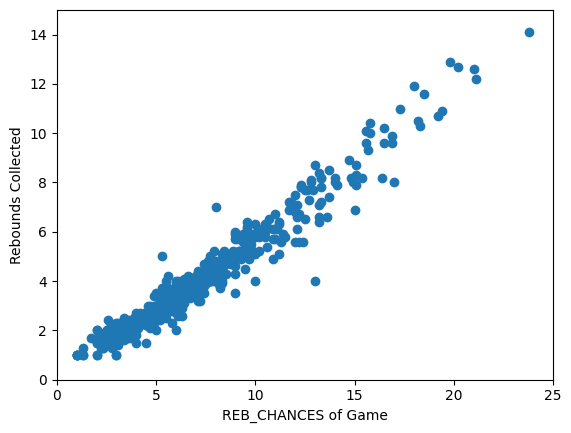

Correlation: 0.973953588669787
R2 Score: 0.9485855928827569


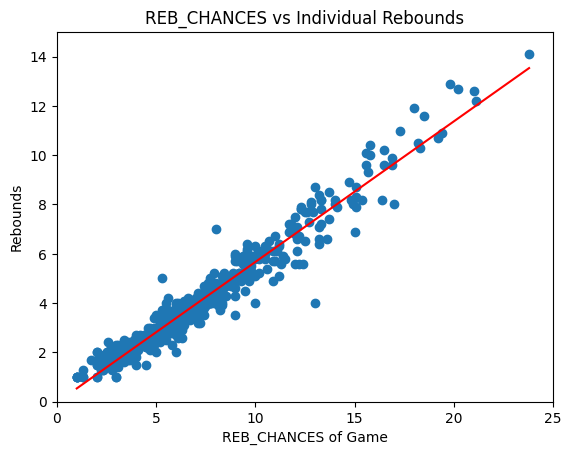

In [11]:
chance_pct_reb = tracking_df[["REB_CHANCES", "REB"]]
# Create your clean analytics sandbox slice
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
chances_reb = tracking_df[["REB_CHANCES", "REB"]]
print("Base Shape:", tracking_df.shape)
print("Final Joined Shape:", tracking_df.shape)
print("Missing Values:\n", chances_reb.isnull().sum())

plt.scatter(chances_reb["REB_CHANCES"], chances_reb["REB"])
plt.xlim(0, 25) # Adjusted boundaries to match real team-wide miss distributions
plt.ylim(0, 15)
plt.xlabel("REB_CHANCES of Game")
plt.ylabel("Rebounds Collected")
plt.show()

print("Correlation:", chances_reb["REB_CHANCES"].corr(chances_reb["REB"]))

# 5. Initialize, Fit, and Execute your Machine Learning Regression
X = chances_reb[["REB_CHANCES"]]
y = chances_reb["REB"]

model = LinearRegression()
model.fit(X, y) # Fit the brain first!
r2 = model.score(X, y)
print("R2 Score:", r2)

# 6. Sort your feature matrix sequentially to draw a crisp trend line
X_sorted = X.sort_values("REB_CHANCES")
predictions_sorted = model.predict(X_sorted)

# 7. Generate your final diagnostic report visualization
plt.scatter(chances_reb["REB_CHANCES"], chances_reb["REB"])
plt.plot(X_sorted["REB_CHANCES"], predictions_sorted, color="red") 

plt.xlim(0, 25)
plt.ylim(0, 15)
plt.xlabel("REB_CHANCES of Game")
plt.ylabel("Rebounds")
plt.title("REB_CHANCES vs Individual Rebounds")
plt.show()


In [ ]:
"""Feature: REB_CHANCES (Raw Tracking Camera Rebound Opportunities)

Relationship: 
Extremely strong, near-perfect positive linear relationship with total REB.

Correlation: 
0.9739

R²: 
0.9485

Why it matters / Basketball Logic: 
The absolute strongest predictor in the entire feature library. Tracking camera 
proximity proves that rebounding volume is entirely dictated by a player's physical 
presence within a 3.5-foot radius of bouncing misses. It cleanly captures 
minutes, tracking positioning, and spatial opportunity in a single metric.

Pregame usable? 
No, must be calculated using historical rolling averages (EWMA Last 5/10 games).

Potential future use: 
Maximum priority core feature. This will act as the absolute primary baseline anchor 
for our predictive machine learning models, effectively dictating 95% of the 
starting projection before environmental adjustments are applied.
"""